Para la extracción de los datos, usamos la API de Binance para conseguir la información de precio de apertura, cierre, entre otras variables, por minuto del bitcoin desde el año 2021 hasta el mes de abril de 2026.

In [ ]:
#Extracción de datos de Binance
import requests, pandas as pd, time
from datetime import datetime

def get_binance_1m(symbol="BTCUSDT", start="2024-01-01", end="2024-01-31"):
    url = "https://api.binance.com/api/v3/klines"
    start_ms = int(datetime.strptime(start, "%Y-%m-%d").timestamp() * 1000)
    end_ms   = int(datetime.strptime(end,   "%Y-%m-%d").timestamp() * 1000)
    all_data = []

    while start_ms < end_ms:
        params = {
            "symbol": symbol,
            "interval": "1m",
            "startTime": start_ms,
            "endTime": end_ms,
            "limit": 1000
        }
        r = requests.get(url, params=params)
        data = r.json()
        if not data: break
        all_data.extend(data)
        start_ms = data[-1][0] + 60000  # avanza 1 minuto
        time.sleep(0.1)  # evita rate limit

    df = pd.DataFrame(all_data, columns=[
        "open_time","open","high","low","close","volume",
        "close_time","quote_volume","trades",
        "taker_buy_base","taker_buy_quote","ignore"
    ])
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
    df[["open","high","low","close","volume"]] = \
        df[["open","high","low","close","volume"]].astype(float)
    return df[["open_time","open","high","low","close","volume","trades"]]

df = get_binance_1m("BTCUSDT", "2021-01-01", "2026-04-01")
df.to_csv("btc_1m_2021_2026.csv", index=False)
print(df.shape)

## 2. Análisis exploratorio de datos

Luego de la descarga de datos, es necesario realizar un análisis exploratorio de los mismos para poder así poder descubrir los patrones que se pueden ver al dar un primer vistazo a los datos y con esto guiar el proceso del modelado.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats

In [ ]:
#Configuración de estilo para gráficos
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False
})

#Carga de los datos
df = pd.read_csv("C:/DL/bitcoin/data/btc_1m_2021_2026.csv", parse_dates=["open_time"])
df = df.set_index("open_time").sort_index()

print(f"Rango temporal : {df.index.min()} → {df.index.max()}")
print(f"Total filas    : {len(df):,}")
print(f"Columnas       : {list(df.columns)}")
print(f"Nulos          : {df.isnull().sum().sum()}")

Rango temporal : 2021-01-01 05:00:00 → 2026-04-01 05:00:00
Total filas    : 2,757,968
Columnas       : ['open', 'high', 'low', 'close', 'volume', 'trades']
Nulos          : 0


In [5]:
df.head()

,open,high,low,close,volume,trades
open_time,,,,,,
2021-01-01 05:00:00,29220.31,29235.28,29193.45,29209.76,59.564319,1054
2021-01-01 05:01:00,29209.76,29213.63,29196.51,29200.72,23.841954,767
2021-01-01 05:02:00,29200.71,29200.72,29159.93,29169.29,69.831118,1144
2021-01-01 05:03:00,29169.30,29175.49,29134.25,29144.93,45.447868,1105
2021-01-01 05:04:00,29144.93,29171.42,29132.23,29164.78,39.387242,917


Dado que no cuenta con valores faltantes, no hace falta pensar en una imputación. Calculemos ahora los **retornos logarítmicos** y la **volatilidad rolling**.

In [6]:
#Retornos logarítmicos sobre precios de cierre
df["log_return"] = np.log(df["close"] / df["close"].shift(1))

#Volatilidad: desviación estándar móvil de los retornos logarítmicos
VOL_WINDOW = 30
df_eda = df.copy()
df_eda["volatility"] = df_eda["log_return"].rolling(window=VOL_WINDOW).std()
df_eda = df_eda.dropna()

print(f"df original  : {len(df):,} filas")
print(f"df_eda       : {len(df_eda):,} filas")
print(f"Filas perdidas por rolling({VOL_WINDOW}): {len(df) - len(df_eda):,}")

df original  : 2,757,968 filas
df_eda       : 2,757,938 filas
Filas perdidas por rolling(30): 30


Decidimos elegir la ventana de 30 minutos para la volatilidad debido a que es un punto medio entre estabilidad estadística y capacidad de respuesta a cambios recientes, y además se ecuentra entre los lags que se van a generar para el modelado (15, 30, 60 y 90 minutos).

In [7]:
tabla_desc = pd.DataFrame({
    "close"      : df_eda["close"].describe(),
    "log_return" : df_eda["log_return"].describe(),
    "volatility" : df_eda["volatility"].describe()
}).round(6)

extra = pd.DataFrame({
    "close"      : {"skewness": df_eda["close"].skew(),
                    "kurtosis": df_eda["close"].kurtosis()},
    "log_return" : {"skewness": df_eda["log_return"].skew(),
                    "kurtosis": df_eda["log_return"].kurtosis()},
    "volatility" : {"skewness": df_eda["volatility"].skew(),
                    "kurtosis": df_eda["volatility"].kurtosis()}
}).round(4)

print("=" * 65)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 65)
print(tabla_desc.to_string())
print()
print("ASIMETRÍA Y CURTOSIS")
print("=" * 65)
print(extra.to_string())

ESTADÍSTICAS DESCRIPTIVAS
              close    log_return    volatility
count  2.757938e+06  2.757938e+06  2.757938e+06
mean   5.544574e+04  0.000000e+00  6.750000e-04
std    2.923660e+04  8.740000e-04  5.570000e-04
min    1.551384e+04 -5.973800e-02  0.000000e+00
25%    2.987102e+04 -3.140000e-04  3.470000e-04
50%    4.809385e+04  0.000000e+00  5.370000e-04
75%    7.075585e+04  3.120000e-04  8.320000e-04
max    1.261145e+05  4.860400e-02  2.500900e-02

ASIMETRÍA Y CURTOSIS
           close  log_return  volatility
skewness  0.6069     -0.1507      5.0947
kurtosis -0.7686     97.1827     77.1743


De estas estadísticas descriptivas podemos resaltar lo siguiente:

- **Alta variabilidad del precio de cierre**: Como sabemos, las criptomonedas suelen ser bastante volátiles, en especial el Bitcoin, por lo que hace sentido la alta variabilidad de la serie que se ve reflejada en el valor de la desviación estandar de aproximadamente 29236.

- Los retornos logarítmicos presentan media cercana a cero, pero una curtosis extremadamente alta (97 aproximadamente), lo que indica la presencia de colas pesadas y eventos extremos frecuentes, característica típica de series financieras. 

- La volatilidad tiene una asimetría de 5.09 y curtosis de 77.17, lo que confirma que la mayoría del tiempo la volatilidad es baja y tranquila, pero hay picos muy abruptos y extremos ocasionales.

Veamos ahora la serie desde 3 puntos de vista: **el precio crudo, los retornos y la volatilidad**.

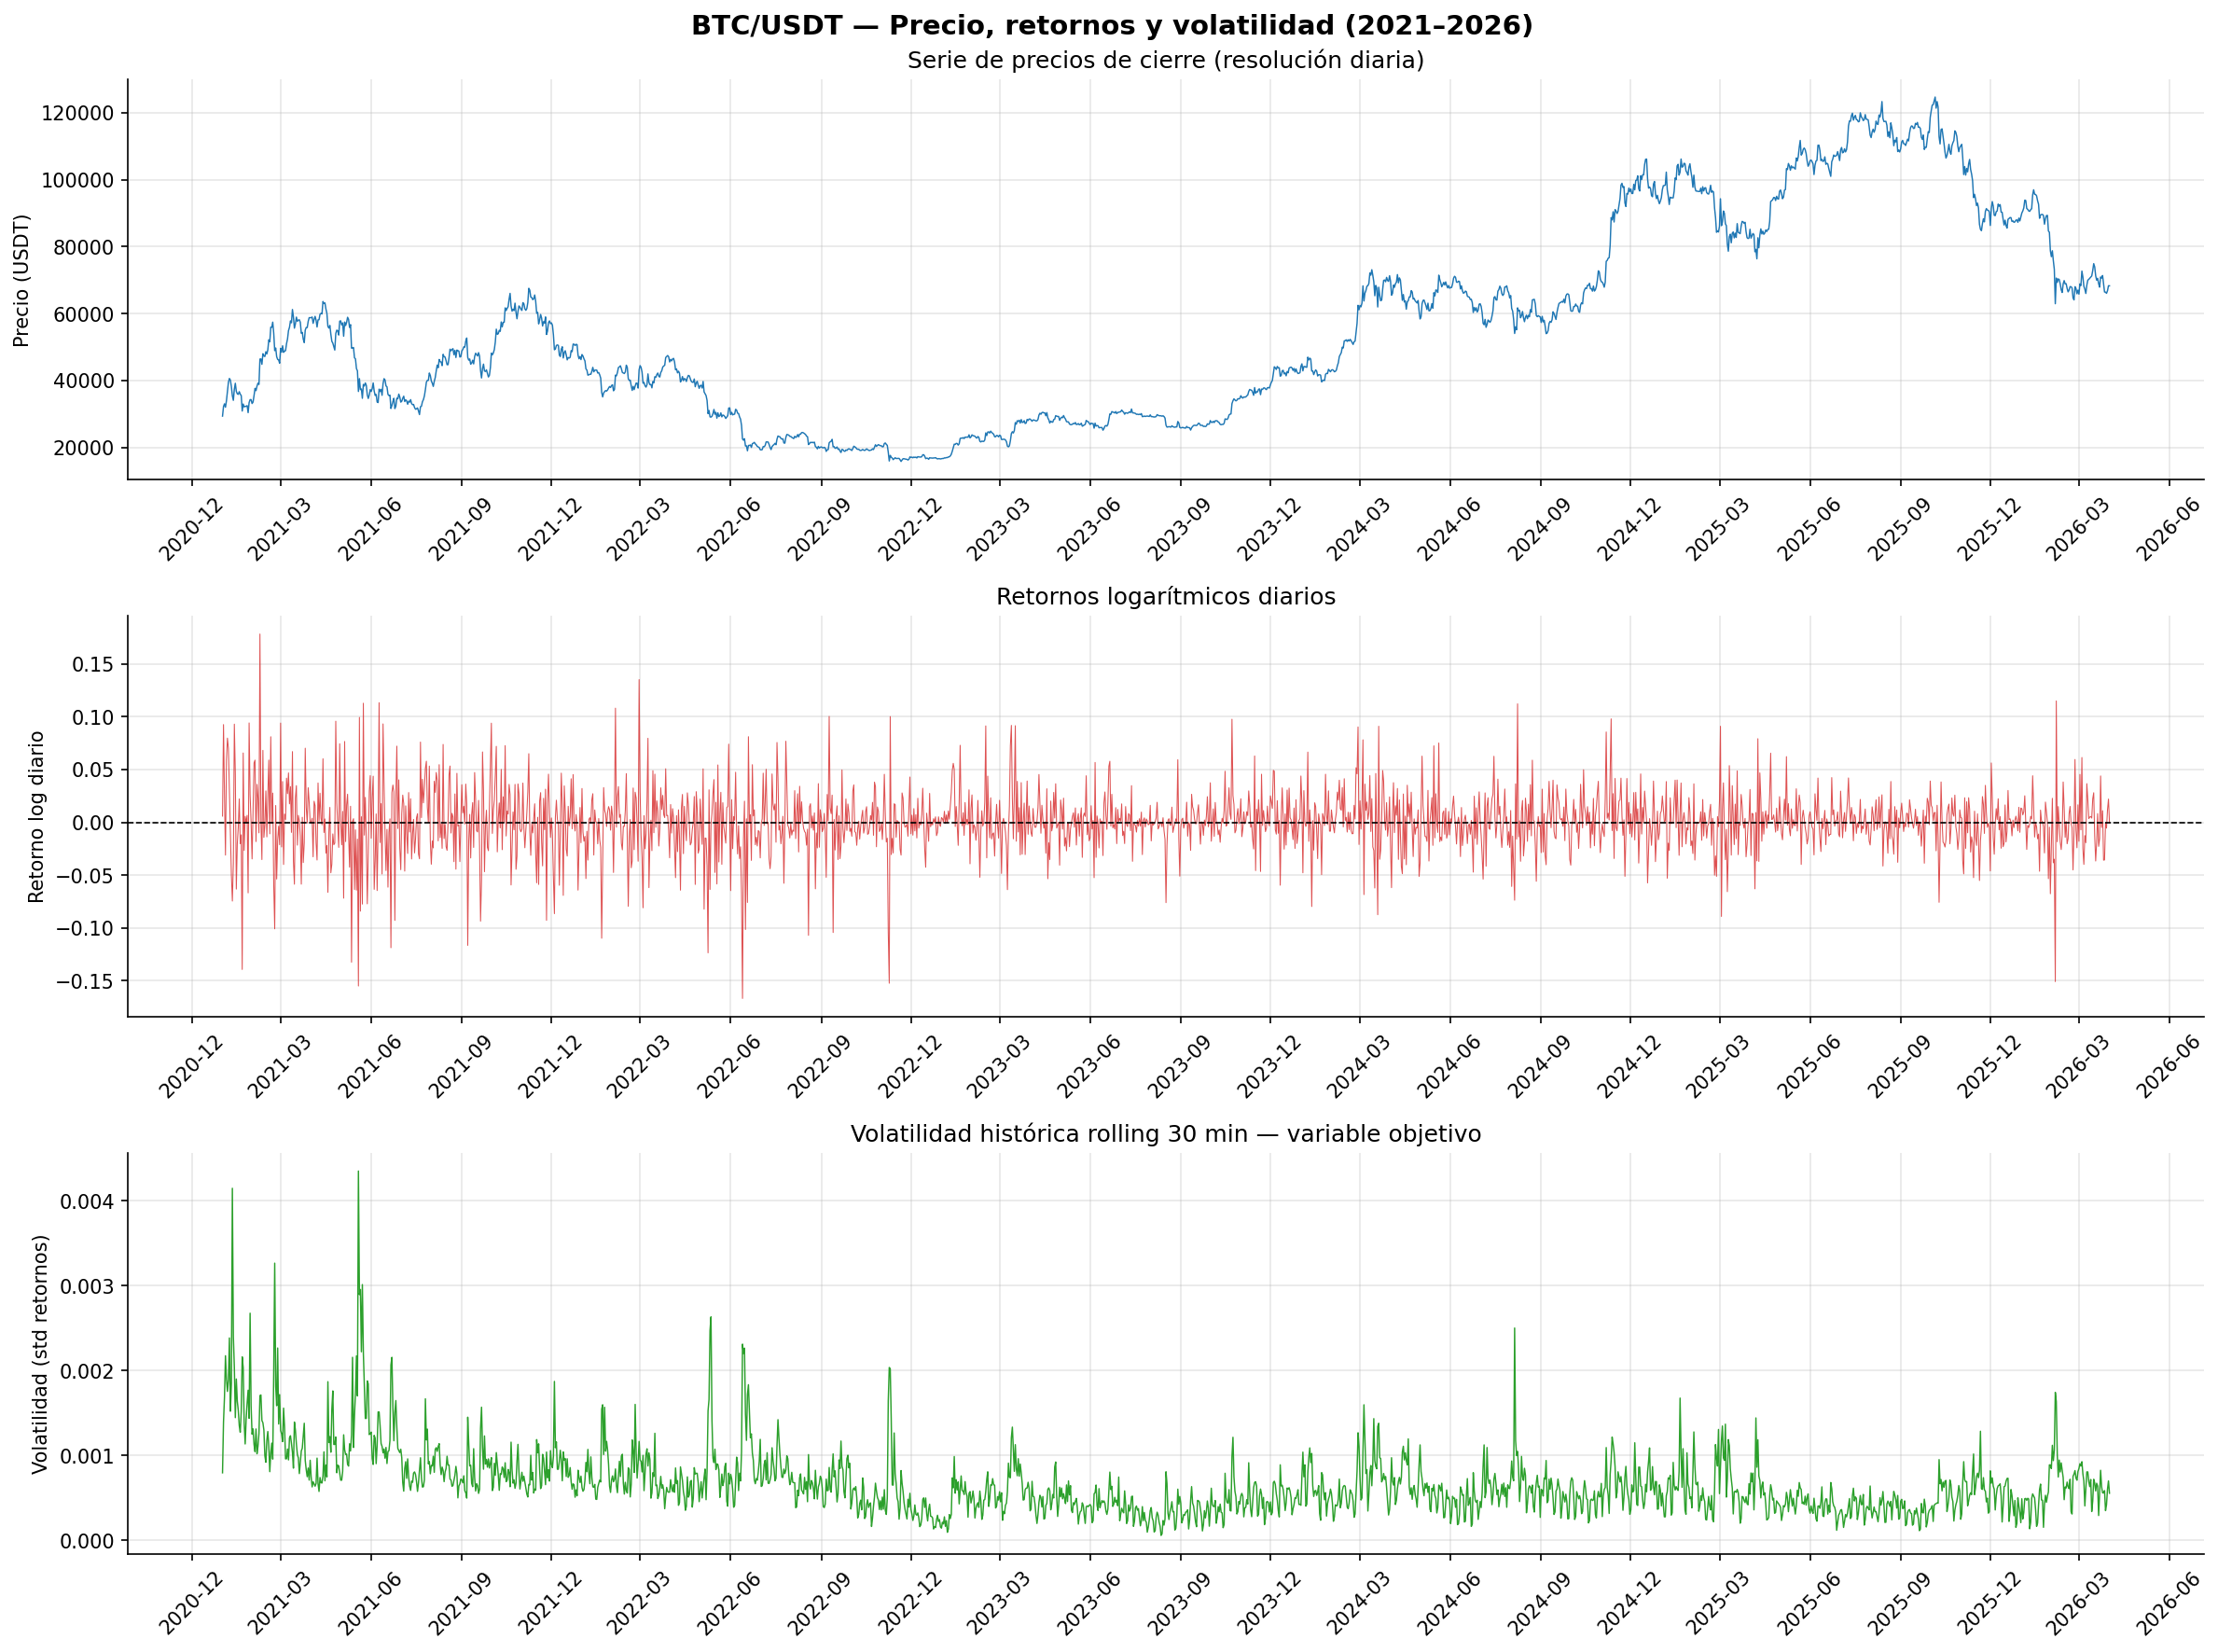

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)
fig.suptitle("BTC/USDT — Precio, retornos y volatilidad (2021–2026)",
             fontsize=14, fontweight="bold")

#Resampleo a diario para visualización
precio_d  = df_eda["close"].resample("1D").last()
retorno_d = df_eda["log_return"].resample("1D").sum()
volatil_d = df_eda["volatility"].resample("1D").mean()

# Panel 1: precio
ax1 = axes[0]
ax1.plot(precio_d.index, precio_d.values, color="#1f77b4", linewidth=0.7)
ax1.set_ylabel("Precio (USDT)")
ax1.set_title("Serie de precios de cierre (resolución diaria)")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Panel 2: retornos diarios
ax2 = axes[1]
ax2.plot(retorno_d.index, retorno_d.values, color="#d62728", linewidth=0.5, alpha=0.8)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_ylabel("Retorno log diario")
ax2.set_title("Retornos logarítmicos diarios")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

# Panel 3: volatilidad rolling
ax3 = axes[2]
ax3.plot(volatil_d.index, volatil_d.values, color="#2ca02c", linewidth=0.7)
ax3.set_ylabel("Volatilidad (std retornos)")
ax3.set_title(f"Volatilidad histórica rolling {VOL_WINDOW} min — variable objetivo")
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

En el primer panel podemos apreciar la **no estacionariedad** del precio de cierre crudo, ya que el mismo varió entre 30k y 70k dólares en 2021, para luego bajar hasta menos de 20k en 2022, y llegar a máximos históricos en 2024 y 2025, lo que nos indica la complejidad de predecir este tipo de series.

En el segundo panel y tercer panel podemos ver reflejada la volatilidad del bitcoin y el pánico que este generó en el mercado en el año 2021 y 2022. Dicha volatilidad se estabilizó después de 2023, con ciertos picos en 2024 y 2026.

Pasemos ahora a una visualización del histograma de los retornos.

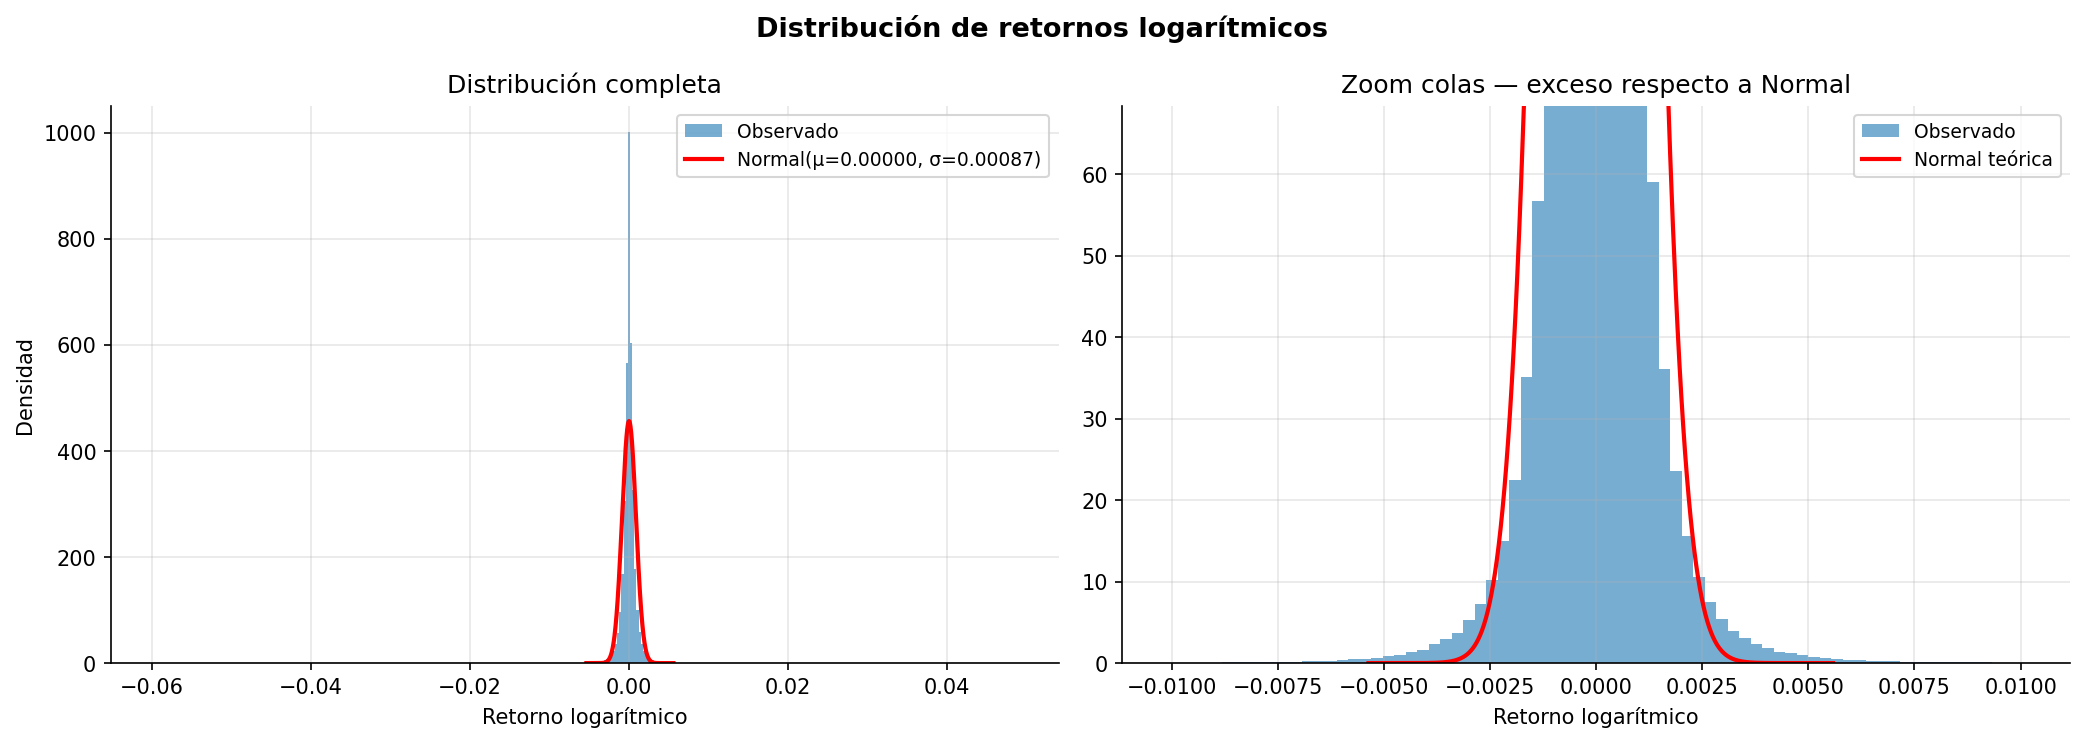

Test Jarque-Bera: estadístico = 1,085,309,134.40,  p-value = 0.00e+00
→ p-value < 0.05: retornos NO son normales


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribución de retornos logarítmicos", fontsize=13, fontweight="bold")

retornos = df_eda["log_return"]
mu, sigma = retornos.mean(), retornos.std()
x = np.linspace(retornos.quantile(0.001), retornos.quantile(0.999), 500)

# Histograma completo
ax1 = axes[0]
ax1.hist(retornos, bins=400, density=True, color="#1f77b4",
         alpha=0.6, label="Observado")
ax1.plot(x, stats.norm.pdf(x, mu, sigma), color="red", linewidth=2,
         label=f"Normal(μ={mu:.5f}, σ={sigma:.5f})")
ax1.set_xlabel("Retorno logarítmico")
ax1.set_ylabel("Densidad")
ax1.set_title("Distribución completa")
ax1.legend(fontsize=9)

# Zoom en colas
ax2 = axes[1]
limite = retornos.quantile(0.999)
ax2.hist(retornos, bins=400, density=True, color="#1f77b4",
         alpha=0.6, label="Observado")
ax2.plot(x, stats.norm.pdf(x, mu, sigma), color="red", linewidth=2,
         label="Normal teórica")
ax2.set_xlim(-limite * 2, limite * 2)
ax2.set_ylim(0, stats.norm.pdf(0, mu, sigma) * 0.15)
ax2.set_xlabel("Retorno logarítmico")
ax2.set_title("Zoom colas — exceso respecto a Normal")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Test Jarque-Bera
jb_stat, jb_pvalue = stats.jarque_bera(retornos)
print(f"Test Jarque-Bera: estadístico = {jb_stat:,.2f},  p-value = {jb_pvalue:.2e}")
print("→ p-value < 0.05: retornos NO son normales" if jb_pvalue < 0.05
      else "→ p-value ≥ 0.05: no se rechaza normalidad")

Tanto con el histograma como con el test `Jarque-Bera`, el cual determina si estos datos siguen una distribución normal basándose en la asimetría y curtosis, nos indican que los retornos no son normales.

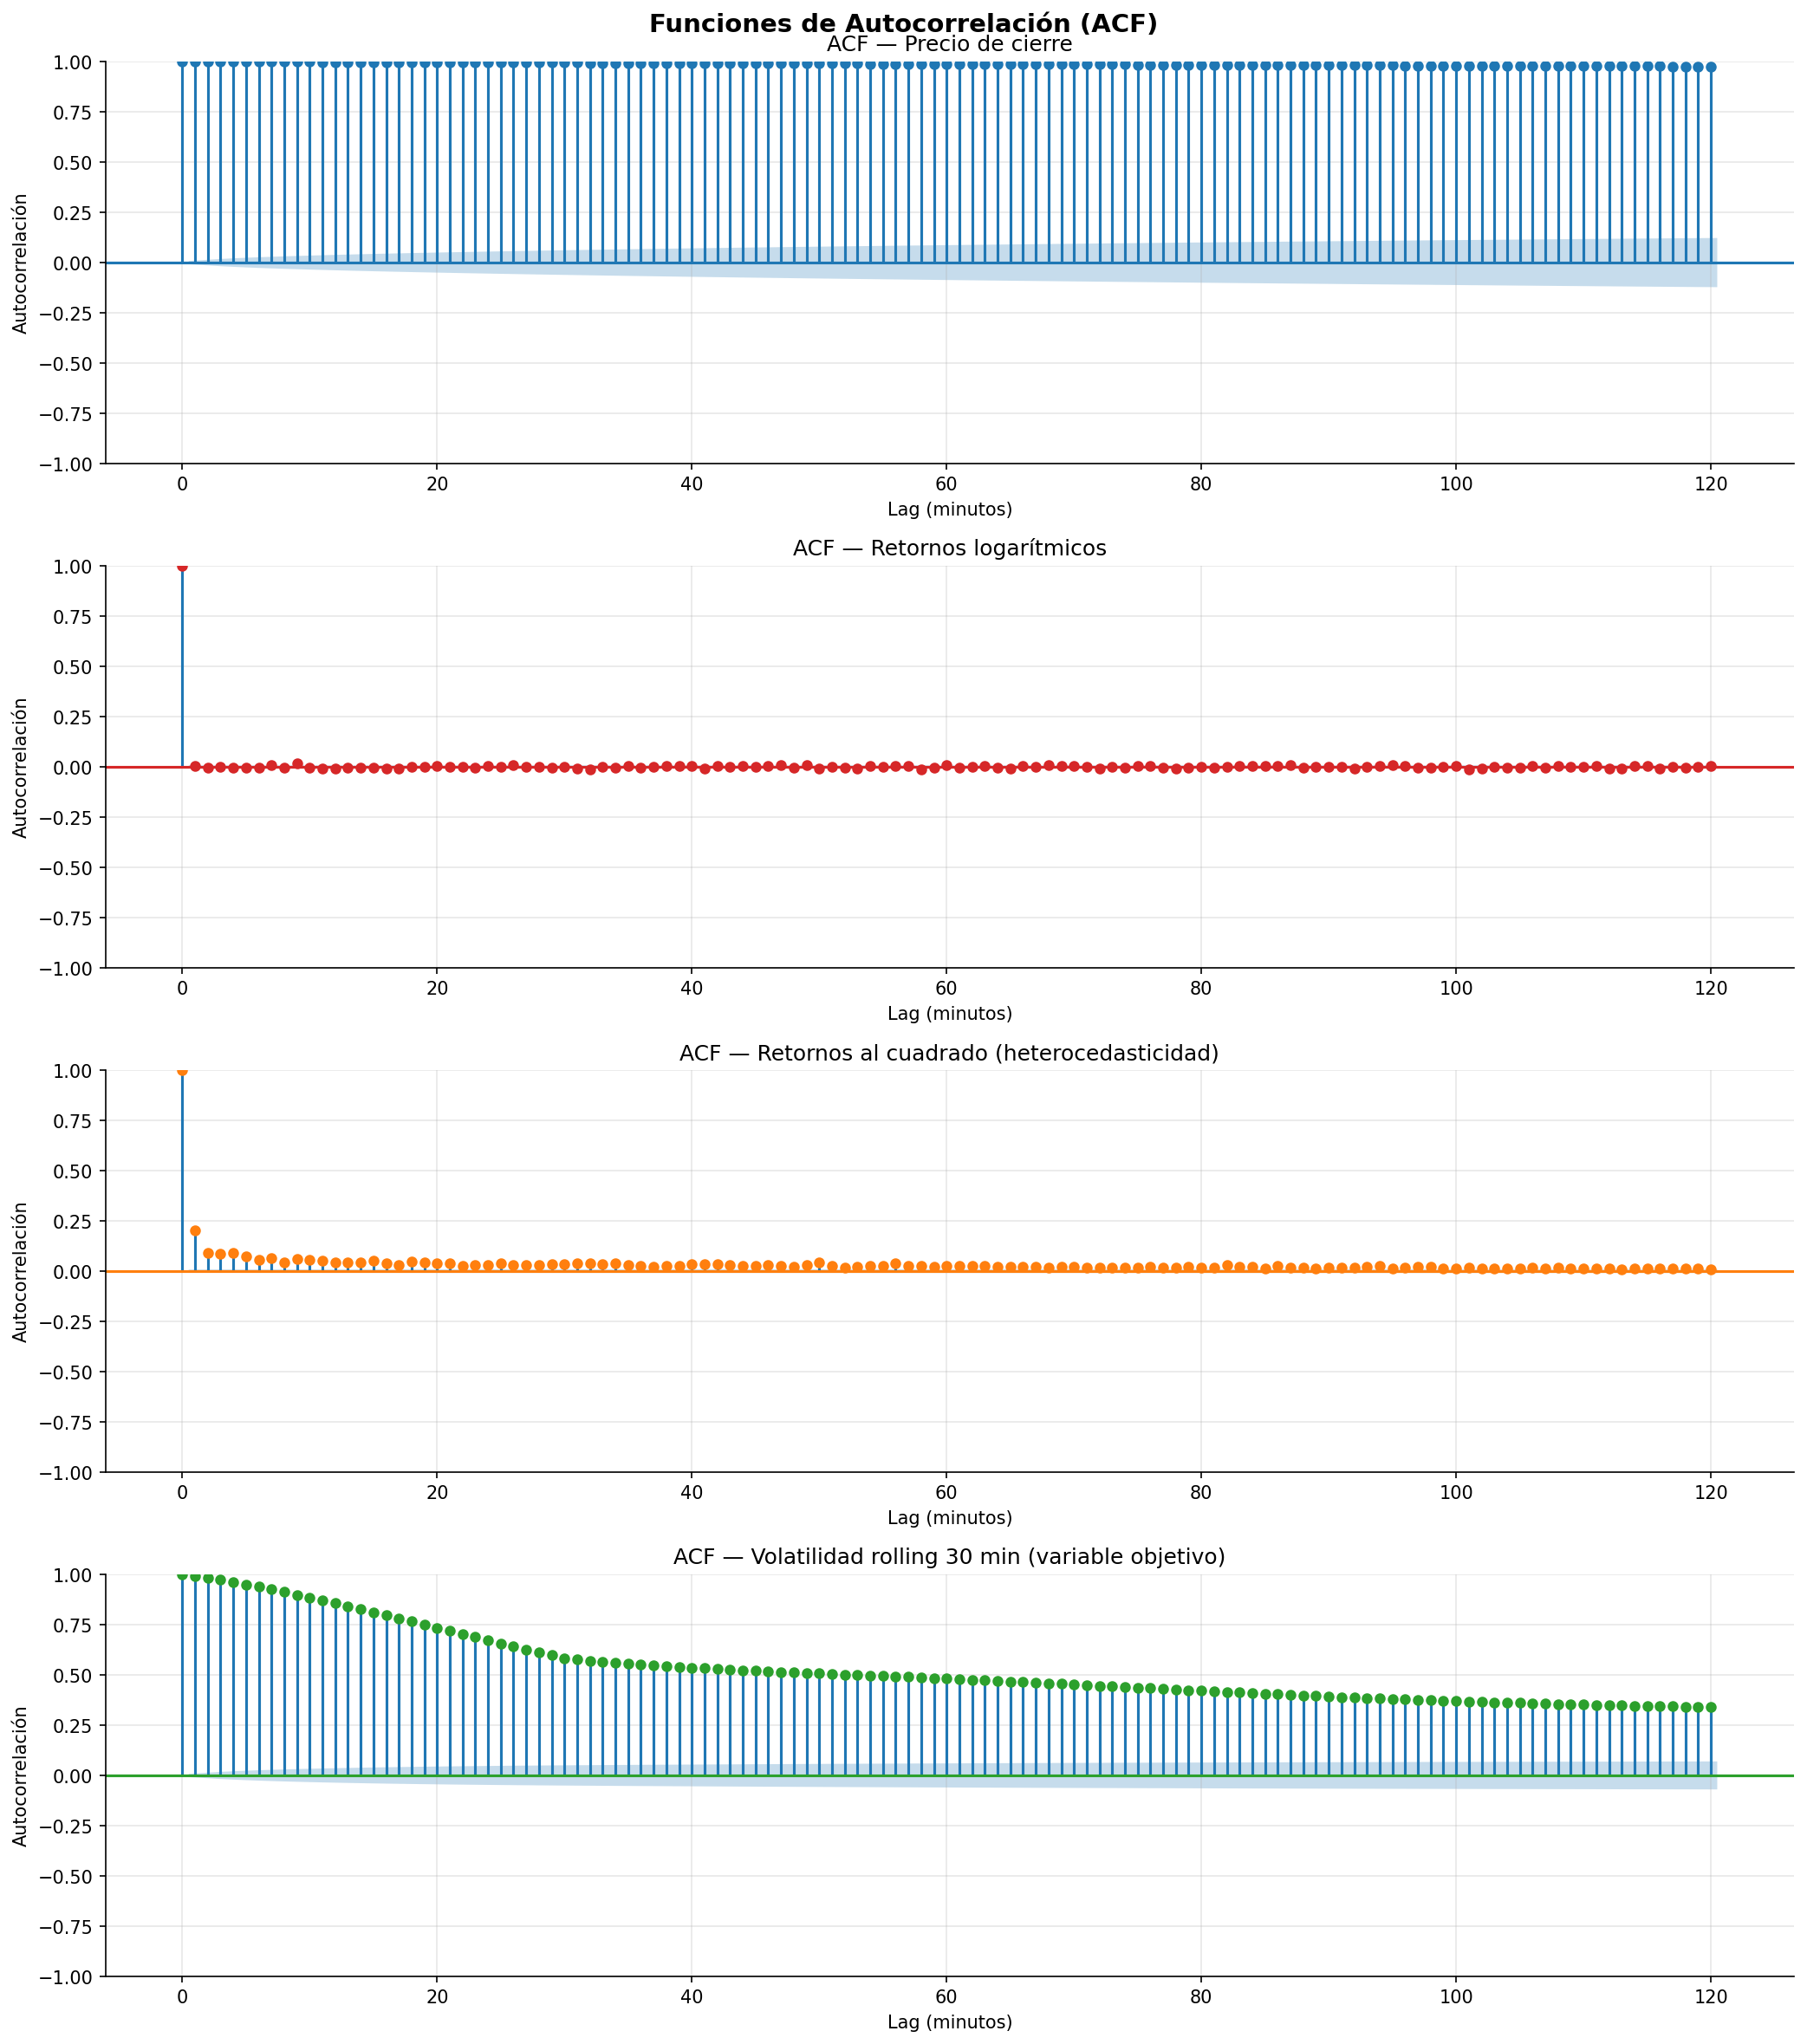

In [10]:
# Muestra representativa: últimos 60,000 minutos ≈ 41 días
N_ACF = 60_000
muestra_close = df_eda["close"].iloc[-N_ACF:]
muestra_ret   = df_eda["log_return"].iloc[-N_ACF:]
muestra_vol   = df_eda["volatility"].iloc[-N_ACF:]

fig, axes = plt.subplots(4, 1, figsize=(14, 16))
fig.suptitle("Funciones de Autocorrelación (ACF)", fontsize=14, fontweight="bold")

plot_acf(muestra_close, lags=120, ax=axes[0], color="#1f77b4", alpha=0.05)
axes[0].set_title("ACF — Precio de cierre")
axes[0].set_xlabel("Lag (minutos)")
axes[0].set_ylabel("Autocorrelación")

plot_acf(muestra_ret, lags=120, ax=axes[1], color="#d62728", alpha=0.05)
axes[1].set_title("ACF — Retornos logarítmicos")
axes[1].set_xlabel("Lag (minutos)")
axes[1].set_ylabel("Autocorrelación")

plot_acf(muestra_ret**2, lags=120, ax=axes[2], color="#ff7f0e", alpha=0.05)
axes[2].set_title("ACF — Retornos al cuadrado (heterocedasticidad)")
axes[2].set_xlabel("Lag (minutos)")
axes[2].set_ylabel("Autocorrelación")

plot_acf(muestra_vol, lags=120, ax=axes[3], color="#2ca02c", alpha=0.05)
axes[3].set_title(f"ACF — Volatilidad rolling {VOL_WINDOW} min (variable objetivo)")
axes[3].set_xlabel("Lag (minutos)")
axes[3].set_ylabel("Autocorrelación")

plt.tight_layout()
plt.show()

El análisis de las funciones de autocorrelación revela patrones fundamentales sobre la estructura temporal de la serie. El ACF del precio de cierre muestra un decaimiento extremadamente lento que se mantiene cercano a 1.0 durante los 120 lags analizados, confirmando que el precio es una serie no estacionaria con tendencia fuerte y memoria muy larga, lo que hace inviable modelarlo directamente sin transformaciones. 

El ACF de los retornos logarítmicos cae abruptamente a cero desde el lag 1 y permanece dentro de la banda de confianza, indicando que los retornos son prácticamente ruido.

Sin embargo, el ACF de los retornos al cuadrado muestra autocorrelaciones significativas en los primeros 10 a 15 lags, evidenciando heterocedasticidad condicional: aunque la dirección del precio no es predecible, su variabilidad sí tiene estructura y memoria.

Finalmente, el ACF de la volatilidad rolling de 30 minutos es el resultado más relevante para este proyecto: las autocorrelaciones son altas y persistentes durante todos los lags analizados, manteniéndose por encima de 0.4 incluso en el lag 120, lo que demuestra que la volatilidad tiene memoria larga y es predecible desde su propio pasado, justificando su elección como variable objetivo del modelo. 

No obstante, siguiendo las indicaciones del proyecto, se utilizarán los lags del precio de cierre close como features de entrada al modelo, dado que representan la información histórica directamente observable de la serie.